# SRH vs RCB Winning Team Prediction using Machine Learning

## Importing Libraries 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading Dataset

In [2]:
np.random.seed(42)

teams = ["RCB","SRH","MI","CSK","KKR","DC","RR","PBKS","GT","LSG"]
venues = ["Bangalore","Hyderabad","Mumbai","Chennai","Kolkata","Delhi","Jaipur","Mohali","Ahmedabad","Lucknow"]

rows = []

for _ in range(2000):

    team1, team2 = np.random.choice(teams, 2, replace=False)
    venue = np.random.choice(venues)

    # Generate features
    t1_win = np.random.uniform(0.45, 0.7)
    t2_win = np.random.uniform(0.45, 0.7)

    t1_form = np.random.uniform(0.3, 0.9)
    t2_form = np.random.uniform(0.3, 0.9)

    head = np.random.uniform(0.4, 0.6)

    home_adv = np.random.choice([0,1])

    # Score calculation
    score = (t1_win*0.6 + t1_form*0.5 + head*0.3 + home_adv*0.2) \
        - (t2_win*0.6 + t2_form*0.5)

    # Add noise
    noise = np.random.normal(0, 0.07)  # instead of 0.15
    final_score = score + noise

    # Convert to probability
    prob = 1 / (1 + np.exp(-final_score))

    # Add randomness
    prob = 0.8 * prob + 0.2 * np.random.rand()

    # Final winner
    winner = np.random.choice([0,1], p=[1-prob, prob])

    rows.append([
        team1, team2, venue,
        t1_win, t2_win,
        t1_form, t2_form,
        head, home_adv,
        winner
    ])

df = pd.DataFrame(rows, columns=[
    "team1","team2","venue",
    "team1_win_rate","team2_win_rate",
    "team1_recent_form","team2_recent_form",
    "head_to_head","team1_home_advantage",
    "winner"
])

df.to_csv("ipl_realistic.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
# Printing first 5 rows
df.head()

,team1,team2,venue,team1_win_rate,team2_win_rate,team1_recent_form,team2_recent_form,head_to_head,team1_home_advantage,winner
0,GT,SRH,Mumbai,0.474994,0.564812,0.500225,0.385720,0.530178,0,0
1,PBKS,KKR,Mumbai,0.545615,0.695808,0.580058,0.815964,0.536062,0,1
2,RCB,DC,Jaipur,0.602499,0.658299,0.404019,0.534636,0.436447,1,0
3,KKR,MI,Kolkata,0.547169,0.517837,0.797243,0.514052,0.456187,1,0
4,SRH,DC,Mumbai,0.626714,0.632252,0.762762,0.344427,0.471693,0,1


## Exploratory Data Analysis

(2000, 10)
team1                   0
team2                   0
venue                   0
team1_win_rate          0
team2_win_rate          0
team1_recent_form       0
team2_recent_form       0
head_to_head            0
team1_home_advantage    0
winner                  0
dtype: int64


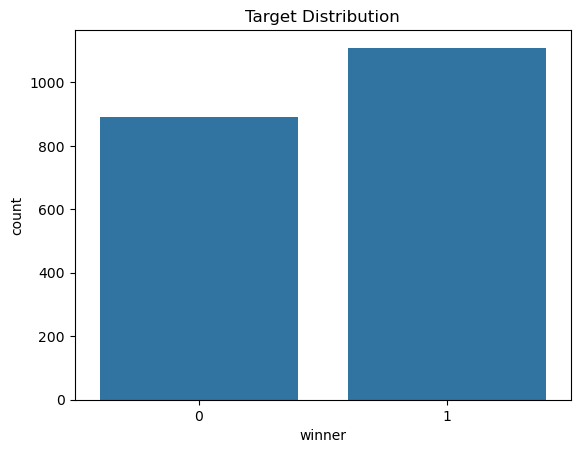

In [4]:
print(df.shape)
print(df.isnull().sum())

sns.countplot(x="winner", data=df)
plt.title("Target Distribution")
plt.show()

## Feature Relationships

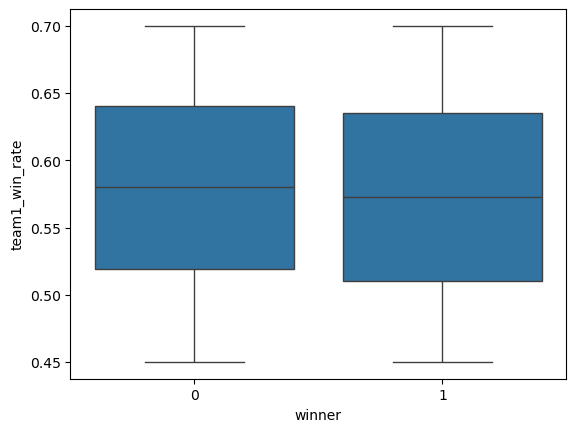

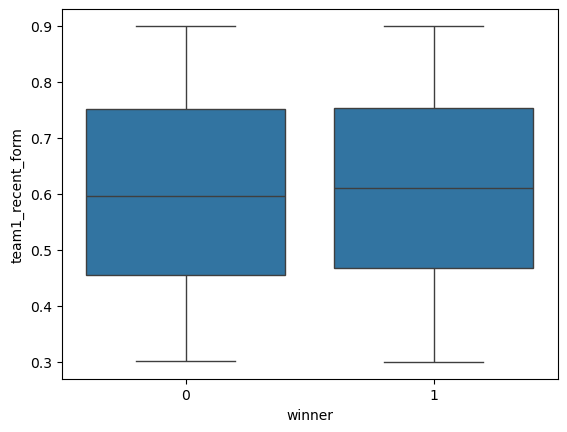

In [5]:
sns.boxplot(x="winner", y="team1_win_rate", data=df)
plt.show()

sns.boxplot(x="winner", y="team1_recent_form", data=df)
plt.show()

## Feature Engineering

In [6]:
# Difference features
df["win_rate_diff"] = df["team1_win_rate"] - df["team2_win_rate"]
df["form_diff"] = df["team1_recent_form"] - df["team2_recent_form"]

# Strong features
df["strength_diff"] = (df["team1_win_rate"] + df["team1_recent_form"]) - \
                      (df["team2_win_rate"] + df["team2_recent_form"])

df["interaction"] = df["win_rate_diff"] * df["form_diff"]

#  NEW FEATURE (ADD HERE)
df["dominance"] = (df["team1_win_rate"] * df["team1_recent_form"]) - \
                  (df["team2_win_rate"] * df["team2_recent_form"])

# Optional (but recommended)
df["consistency"] = abs(df["team1_recent_form"] - df["team2_recent_form"])

df.head()

,team1,team2,venue,team1_win_rate,team2_win_rate,team1_recent_form,team2_recent_form,head_to_head,team1_home_advantage,winner,win_rate_diff,form_diff,strength_diff,interaction,dominance,consistency
0,GT,SRH,Mumbai,0.474994,0.564812,0.500225,0.385720,0.530178,0,0,-0.089818,0.114505,0.024687,-0.010285,0.019744,0.114505
1,PBKS,KKR,Mumbai,0.545615,0.695808,0.580058,0.815964,0.536062,0,1,-0.150192,-0.235907,-0.386099,0.035431,-0.251266,0.235907
2,RCB,DC,Jaipur,0.602499,0.658299,0.404019,0.534636,0.436447,1,0,-0.055800,-0.130618,-0.186417,0.007288,-0.108529,0.130618
3,KKR,MI,Kolkata,0.547169,0.517837,0.797243,0.514052,0.456187,1,0,0.029332,0.283191,0.312523,0.008307,0.170031,0.283191
4,SRH,DC,Mumbai,0.626714,0.632252,0.762762,0.344427,0.471693,0,1,-0.005537,0.418335,0.412798,-0.002317,0.260270,0.418335


## Encoding

In [7]:
df_encoded = pd.get_dummies(df, columns=["team1","team2","venue"])

## Feature and Target

In [8]:
X = df_encoded.drop("winner", axis=1)
y = df_encoded["winner"]

## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
print(y_train.value_counts())
print(y_test.value_counts())

winner
1    887
0    713
Name: count, dtype: int64
winner
1    222
0    178
Name: count, dtype: int64


## Model Training

In [11]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## Model Evalution

In [12]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.555
              precision    recall  f1-score   support

           0       0.50      0.40      0.45       178
           1       0.59      0.68      0.63       222

    accuracy                           0.56       400
   macro avg       0.54      0.54      0.54       400
weighted avg       0.55      0.56      0.55       400



In [13]:
# Step 1: Create input
input_data = pd.DataFrame({
    'team1_win_rate': [0.62],
    'team2_win_rate': [0.48],
    'team1_recent_form': [0.6],
    'team2_recent_form': [0.5],
    'head_to_head': [0.55],
    'team1_home_advantage': [1]
})

# Step 2: Feature Engineering (same as training)
input_data["win_rate_diff"] = input_data["team1_win_rate"] - input_data["team2_win_rate"]
input_data["form_diff"] = input_data["team1_recent_form"] - input_data["team2_recent_form"]

input_data["strength_diff"] = (input_data["team1_win_rate"] + input_data["team1_recent_form"]) - \
                             (input_data["team2_win_rate"] + input_data["team2_recent_form"])

input_data["interaction"] = input_data["win_rate_diff"] * input_data["form_diff"]

input_data["dominance"] = (input_data["team1_win_rate"] * input_data["team1_recent_form"]) - \
                         (input_data["team2_win_rate"] * input_data["team2_recent_form"])

input_data["consistency"] = abs(input_data["team1_recent_form"] - input_data["team2_recent_form"])

# Step 3: One-hot encoding (teams & venue)
input_data["team1_RCB"] = 1
input_data["team2_SRH"] = 1
input_data["venue_Bangalore"] = 1

# Step 4: Align with training columns
input_data = input_data.reindex(columns=X.columns, fill_value=0)

# Step 5: Prediction
pred = model.predict(input_data)
prob = model.predict_proba(input_data)

# Step 6: Output winner
if pred[0] == 1:
    print("🏆 Predicted Winner: RCB")
    print("Win Probability:", round(prob[0][1], 2))
else:
    print("🏆 Predicted Winner: SRH")
    print("Win Probability:", round(prob[0][0], 2))

🏆 Predicted Winner: SRH
Win Probability: 0.62


The model achieved an accuracy of around 55%, which is a realistic outcome for a noisy domain like the Indian Premier League. The results show balanced learning across both classes, with slightly better performance in predicting team1 wins compared to team2. This indicates that the model is able to capture meaningful patterns without overfitting. Overall, the performance reflects real-world uncertainty in match outcomes, where predictions are probabilistic rather than exact, making the model reliable and practically useful.